# Notebook for practical exercises | Week #4 Lesson #1

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Convolutional Neural Networks for Classification and Detection*.

After this session, you will know how to fine‑tune a pretrained CNN on a real-world clinical problem:
* Classifying pneumonia vs. healthy control from chest X-rays using different model architectures.
* Building a model to detect pneumonia from chest X-rays using different model architectures.
* Reporting evaluation metrics and justifying the choice of model architecture.

## Dataset

We will use the dataset from the [RSNA Pneumonia Detection Challenge](https://www.kaggle.com/competitions/rsna-pneumonia-detection-challenge/overview).

In this challenge competitors are predicting whether pneumonia exists in a given image. They do so by predicting bounding boxes around areas of the lung. Samples without bounding boxes are negative and contain no definitive evidence of pneumonia. Samples with bounding boxes indicate evidence of pneumonia.

When making predictions, competitors should predict as many bounding boxes as they feel are necessary, in the format:
confidence x-min y-min width height

All provided images are in DICOM format. Data fields availables in the `labels.csv` file are the following:
* patientId _- A patientId. Each patientId corresponds to a unique image.
* x_ - the upper-left x coordinate of the bounding box.
* y_ - the upper-left y coordinate of the bounding box.
* width_ - the width of the bounding box.
* height_ - the height of the bounding box.
* Target_ - the binary Target, indicating whether this sample has evidence of pneumonia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

!pip install pydicom
import pydicom
import time
import cv2
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import tv_tensors
import torchvision
from torchvision.transforms import v2 as T
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.6 MB/s eta 0:00:00


### Download

If needed, run the following cells to download and unzip the dataset.

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
<b>If you have already downloaded the dataset, comment the following cell by adding a <code>#</code> before the <code>!</code></b>
</div>

In [2]:
DATA_PATH = '../..'

if not os.path.exists(f'{DATA_PATH}/data'):
    os.mkdir(f'{DATA_PATH}/data')

!curl https://uni-bonn.sciebo.de/s/qAeDDC5HkigwF5c/download --output {DATA_PATH}/data/rsna-pneumonia-detection-challenge.zip
!unzip {DATA_PATH}/data/rsna-pneumonia-detection-challenge.zip -d {DATA_PATH}/data

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: ../../data/rsna-pneumonia-detection-challenge/images/f868de0f-be9e-4da2-aee7-b0bc5b66e086.dcm  
  inflating: ../../data/__MACOSX/rsna-pneumonia-detection-challenge/images/._f868de0f-be9e-4da2-aee7-b0bc5b66e086.dcm  
  inflating: ../../data/rsna-pneumonia-detection-challenge/images/bfdbe64f-1ab9-4b72-a4b5-3ef6a057add2.dcm  
  inflating: ../../data/__MACOSX/rsna-pneumonia-detection-challenge/images/._bfdbe64f-1ab9-4b72-a4b5-3ef6a057add2.dcm  
  inflating: ../../data/rsna-pneumonia-detection-challenge/images/4dbc44ca-694a-4814-9a24-bc60c8d8d611.dcm  
  inflating: ../../data/__MACOSX/rsna-pneumonia-detection-challenge/images/._4dbc44ca-694a-4814-9a24-bc60c8d8d611.dcm  
  inflating: ../../data/rsna-pneumonia-detection-challenge/images/eb056e61-98f0-418d-a5e9-b82bd8d2db93.dcm  
  inflating: ../../data/__MACOSX/rsna-pneumonia-detection-challenge/images/._eb056e61-98f0-418d-a5e9-b82bd8d2db93.dcm  
  infl

<div class="alert alert-block alert-danger">
<b>In case you have low computational power, you can run the train cells only to verify they are correctly running, and use the pretrained models for inference. Use the cell below to download them.</b> <br>
</div>

## Classification

This week, to learn how to work with deep models such as CNNs, we will use the PyTorch library.

### Datasets in PyTorch

PyTorch has two primitives to work with data: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`. Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset.
PyTorch offers domain-specific libraries such as TorchText, TorchVision, and TorchAudio, all of which include datasets. For this tutorial, we will be using a custom TorchVision dataset.

In [3]:
class ClassificationDataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        super().__init__()

        self.image_ids = dataframe['patientId'].unique()
        self.df = dataframe
        self.image_dir = image_dir
        self.transforms = transforms

    def __getitem__(self, index: int):

        image_id = self.image_ids[index]
        records = self.df[self.df['patientId'] == image_id]

        image_dicom = pydicom.dcmread(f'{self.image_dir}/{image_id}.dcm')
        image = image_dicom.pixel_array
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB).astype(np.float32)
        image /= 255.0
        image = np.transpose(image, (2, 0, 1))
        image = tv_tensors.Image(image)
        # Define the transform
        resize_transform = torchvision.transforms.Resize((128, 128))
        # Apply the transform
        resized_img = resize_transform(image)

        # there is only one class
        labels = torch.tensor(records['Target'].values[0])

        return image, labels

    def __len__(self) -> int:
        return self.image_ids.shape[0]

Transforms are modifications made to the samples during loading. During training, it can include some data augmentation strategies.

In [4]:
def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [5]:
image_dir = f'{DATA_PATH}/data/rsna-pneumonia-detection-challenge/images'
dataset_df = pd.read_csv(f'{DATA_PATH}/data/rsna-pneumonia-detection-challenge/labels.csv')
dataset_df = dataset_df.sample(1000)
patient_list = dataset_df['patientId'].unique()

patient_train, patient_test = train_test_split(
    patient_list, # List or array to split
    test_size=0.2, # Size of the subset
    random_state=42)

patient_train, patient_val = train_test_split(
    patient_train,
    test_size=0.1 / 0.8,
    random_state=42)

train_df = dataset_df.loc[dataset_df['patientId'].isin(patient_train)]
val_df = dataset_df.loc[dataset_df['patientId'].isin(patient_val)]

In [6]:
train_dataset = ClassificationDataset(train_df, image_dir, transforms=get_transform(True))

<div class="alert alert-block alert-info">
<b>Q1.</b> Similarly, create a <code>val_dataset</code> variable to store the validation set.
</div>

In [7]:
val_dataset = ClassificationDataset(val_df, image_dir,  transforms=get_transform(False))

We pass the `Dataset` as an argument to `DataLoader`. This wraps an iterable over our dataset, and supports automatic batching, sampling, shuffling and multiprocess data loading. Here we define a batch size of 32, *i.e.* each element in the dataloader iterable will return a batch of 32 features and labels.

In [8]:
batch_size = 32

# Create data loaders.
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([32, 3, 1024, 1024])
Shape of y: torch.Size([32]) torch.int64


### Loading pretrained models with PyTorch

The `torchvision.models` subpackage contains definitions of models for addressing different tasks, including: image classification, pixelwise semantic segmentation, object detection, instance segmentation, person keypoint detection, video classification, and optical flow.

TorchVision offers a new mechanism which allows listing and retrieving models and weights by their names. Here are a few examples on how to use them:

In [9]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [10]:
from torchvision.models import resnet18, ResNet18_Weights

# Initialize model with the best available weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 224MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Hyperparameters

Hyperparameters are adjustable parameters that let you control the model optimization process. Different hyperparameter values can impact model training and convergence rates.

We define the following hyperparameters for training:
* Number of Epochs - the number of times to iterate over the dataset
* Batch Size - the number of data samples propagated through the network before the parameters are updated
* Learning Rate - how much to update models parameters at each batch/epoch. Smaller values yield slow learning speed, while large values may result in unpredictable behavior during training.

In [11]:
learning_rate = 1e-4
batch_size = 32
epochs = 5

### Optimization loop

Once we set our hyperparameters, we can then train and optimize our model with an optimization loop. Each iteration of the optimization loop is called an epoch.

Each epoch consists of two main parts:
* The Train Loop - iterate over the training dataset and try to converge to optimal parameters.
* The Validation/Test Loop - iterate over the test dataset to check if model performance is improving on unseen data.

When presented with some training data, our untrained network is likely not to give the correct answer. Loss function measures the degree of dissimilarity of obtained result to the target value, and it is the loss function that we want to minimize during training. To calculate the loss we make a prediction using the inputs of our given data sample and compare it against the true data label value.

We pass our model’s output logits to `nn.CrossEntropyLoss`, which will normalize the logits and compute the prediction error.

In [12]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

Optimization is the process of adjusting model parameters to reduce model error in each training step. Optimization algorithms define how this process is performed (in this example we use Stochastic Gradient Descent). All optimization logic is encapsulated in the optimizer object. Here, we use the SGD optimizer; additionally, there are many different optimizers available in PyTorch such as ADAM and RMSProp, that work better for different kinds of models and data.

We initialize the optimizer by registering the model’s parameters that need to be trained, and passing in the learning rate hyperparameter.

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Inside the training loop, optimization happens in three steps:
* Call `optimizer.zero_grad()` to reset the gradients of model parameters. Gradients by default add up; to prevent double-counting, we explicitly zero them at each iteration.
* Backpropagate the prediction loss with a call to `loss.backward()`. PyTorch deposits the gradients of the loss w.r.t. each parameter.
* Once we have our gradients, we call `optimizer.step()` to adjust the parameters by the gradients collected in the backward pass.

In [14]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def train_loop(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    # Set the model to training mode
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    return model

def val_loop(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

#### Overall optimization process

<div class="alert alert-block alert-info">
<b>Q2.</b> Run the following cell to visualize the overall optimization process.
</div>

In [15]:
learning_rate = 1e-4
batch_size = 32
epochs = 5

weights = ResNet18_Weights.DEFAULT

model_resnet = resnet18(weights=weights)
model_resnet.fc = nn.Linear(512, 2)
preprocess = weights.transforms()

optimizer = torch.optim.Adam(model_resnet.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

train_dataset = ClassificationDataset(train_df, image_dir, transforms=preprocess)
val_dataset = ClassificationDataset(val_df, image_dir,  transforms=preprocess)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

model_resnet.to(device)
loss_fn.to(device)

s = time.process_time() # start time
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    model_resnet = train_loop(train_dataloader, model_resnet, loss_fn, optimizer, device)
    val_loop(val_dataloader, model_resnet, loss_fn, device)
print("Done!")

torch.save(model_resnet.state_dict, './resnet18-pneumonia-lr1e-4-b32-e5.pth')

e = time.process_time() # end time
print(e - s, "seconds")

Epoch 1
-------------------------------
loss: 0.632762  [   32/  695]
Error: 
 Accuracy: 71.0%, Avg loss: 0.528028 

Epoch 2
-------------------------------
loss: 0.384365  [   32/  695]
Error: 
 Accuracy: 83.0%, Avg loss: 0.386673 

Epoch 3
-------------------------------
loss: 0.365591  [   32/  695]
Error: 
 Accuracy: 76.0%, Avg loss: 0.445421 

Epoch 4
-------------------------------
loss: 0.092477  [   32/  695]
Error: 
 Accuracy: 77.0%, Avg loss: 0.470802 

Epoch 5
-------------------------------
loss: 0.028910  [   32/  695]
Error: 
 Accuracy: 83.0%, Avg loss: 0.407680 

Done!
331.72086853400003 seconds


In [16]:
#model_resnet.load_state_dict(torch.load('./resnet18-pneumonia-lr1e-4-b32-e5.pth', map_location=device)) #Uncomment to use pretrained models

### Benchmarking model architectures

CNN architectures differ primarily in their layer arrangements, use of skip connections, and strategies for dealing with vanishing gradients, impacting their ability to scale and learn complex features. Some architectures, like ResNet, use skip connections to bypass layers, enabling deeper networks without vanishing gradients, while others, like DenseNet, employ dense connectivity within blocks. Other variations include Inception modules for parallel processing and feature combination, and normalization layers to stabilize training.

In the following, you will train different model architecture and compare the performance you obtain on the validation set.

<div class="alert alert-block alert-info">
<b>Q3.</b> Complete the following cells to train other model architectures: <br>
    - AlexNet <br>
    - EfficientNet <br>
    - Swin transformer <br>
</div>

#### AlexNet

In [17]:
from torchvision.models import alexnet, AlexNet_Weights

learning_rate = 1e-4
batch_size = 32
epochs = 5

model_alexnet = alexnet(weights='DEFAULT')
model_alexnet.classifier[6] = nn.Linear(4096, 2)

preprocess = AlexNet_Weights.DEFAULT.transforms()

train_dataset = ClassificationDataset(train_df, image_dir, transforms=preprocess)
val_dataset = ClassificationDataset(val_df, image_dir,  transforms=preprocess)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_alexnet.parameters(), lr=learning_rate)

model_alexnet.to(device)
loss_fn.to(device)

s = time.process_time() # start time
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    model_alexnet = train_loop(train_dataloader, model_alexnet, loss_fn, optimizer, device)
    val_loop(val_dataloader, model_alexnet, loss_fn, device)
print("Done!")

torch.save(model_alexnet.state_dict, './alexnet-pneumonia-lr1e-4-b32-e5.pth')

e = time.process_time() # end time
print(e - s, "seconds")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 234MB/s]


Epoch 1
-------------------------------
loss: 0.690847  [   32/  695]
Error: 
 Accuracy: 72.0%, Avg loss: 0.575146 

Epoch 2
-------------------------------
loss: 0.496034  [   32/  695]
Error: 
 Accuracy: 74.0%, Avg loss: 0.545716 

Epoch 3
-------------------------------
loss: 0.622956  [   32/  695]
Error: 
 Accuracy: 77.0%, Avg loss: 0.464398 

Epoch 4
-------------------------------
loss: 0.305396  [   32/  695]
Error: 
 Accuracy: 73.0%, Avg loss: 0.609527 

Epoch 5
-------------------------------
loss: 0.653963  [   32/  695]
Error: 
 Accuracy: 68.0%, Avg loss: 0.551026 

Done!
274.32890864 seconds


In [18]:
#model_alexnet.load_state_dict(torch.load('./alexnet-pneumonia-lr1e-4-b32-e5.pth', map_location=device)) #Uncomment to use pretrained models

#### EfficientNet

In [19]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

learning_rate = 1e-4
batch_size = 8
epochs = 5

model_enb0 = efficientnet_b0(weights='DEFAULT')
model_enb0.classifier[1] = nn.Linear(1280, 2)

preprocess = EfficientNet_B0_Weights.DEFAULT.transforms()

train_dataset = ClassificationDataset(train_df, image_dir, transforms=get_transform(True))
val_dataset = ClassificationDataset(val_df, image_dir,  transforms=get_transform(False))

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_enb0.parameters(), lr=learning_rate)

model_enb0.to(device)
loss_fn.to(device)

s = time.process_time() # start time
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    model_enb0 = train_loop(train_dataloader, model_enb0, loss_fn, optimizer, device)
    val_loop(val_dataloader, model_enb0, loss_fn, device)
print("Done!")

torch.save(model_enb0.state_dict, './efficientnetb0-pneumonia-lr1e-4-b32-e5.pth')

e = time.process_time() # end time
print(e - s, "seconds")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 223MB/s]


Epoch 1
-------------------------------
loss: 0.694895  [    8/  695]
Error: 
 Accuracy: 80.0%, Avg loss: 0.453951 

Epoch 2
-------------------------------
loss: 0.387305  [    8/  695]
Error: 
 Accuracy: 84.0%, Avg loss: 0.406885 

Epoch 3
-------------------------------
loss: 0.279074  [    8/  695]
Error: 
 Accuracy: 84.0%, Avg loss: 0.415263 

Epoch 4
-------------------------------
loss: 0.341714  [    8/  695]
Error: 
 Accuracy: 79.0%, Avg loss: 0.423461 

Epoch 5
-------------------------------
loss: 0.340811  [    8/  695]
Error: 
 Accuracy: 81.0%, Avg loss: 0.670243 

Done!
446.481899323 seconds


In [20]:
#model_enb0.load_state_dict(torch.load('./efficientnetb0-pneumonia-lr1e-4-b32-e5.pth', map_location=device)) #Uncomment to use pretrained models

#### Swin transformer

In [21]:
from torchvision.models import swin_t, Swin_T_Weights
import time
learning_rate = 1e-4
batch_size = 8
epochs = 5

model_swin = swin_t(weights='DEFAULT')
model_swin.head = nn.Linear(in_features=768, out_features=2, bias=True)

preprocess = Swin_T_Weights.DEFAULT.transforms()

train_dataset = ClassificationDataset(train_df, image_dir, transforms=get_transform(True))
val_dataset = ClassificationDataset(val_df, image_dir,  transforms=get_transform(False))

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_swin.parameters(), lr=learning_rate)

model_swin.to(device)
loss_fn.to(device)

s = time.process_time() # start time
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    model_swin = train_loop(train_dataloader, model_swin, loss_fn, optimizer, device)
    val_loop(val_dataloader, model_swin, loss_fn, device)
print("Done!")

torch.save(model_swin.state_dict, './swint-pneumonia-lr1e-4-b32-e5.pth')

e = time.process_time() # end time
print(e - s, "seconds")

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth
100%|██████████| 108M/108M [00:00<00:00, 231MB/s] 


Epoch 1
-------------------------------
loss: 0.684283  [    8/  695]
Error: 
 Accuracy: 71.0%, Avg loss: 0.709629 

Epoch 2
-------------------------------
loss: 0.910957  [    8/  695]
Error: 
 Accuracy: 71.0%, Avg loss: 0.612632 

Epoch 3
-------------------------------
loss: 0.822052  [    8/  695]
Error: 
 Accuracy: 71.0%, Avg loss: 0.622317 

Epoch 4
-------------------------------
loss: 0.422385  [    8/  695]
Error: 
 Accuracy: 71.0%, Avg loss: 0.642735 

Epoch 5
-------------------------------
loss: 0.734810  [    8/  695]
Error: 
 Accuracy: 71.0%, Avg loss: 0.611167 

Done!
895.834112297 seconds


In [22]:
#model_swin.load_state_dict(torch.load('./swint-pneumonia-lr1e-4-b32-e5.pth', map_location=device)) # Uncomment to use pretrained models

#### Metrics

Now that we have trained our models, we can evaluate their performance on the validation set using different metrics to select the best performing one.

<div class="alert alert-block alert-info">
<b>Q4.</b> Compare the performance of the four models using appropriate metrics: <br>
    - Plot the ROC curve <br>
    - Accuracy score <br>
    - Precision and Recall <br>
    - F1-score <br>
    - etc.
</div>

Accuracy: 1.0 
F1-score: 1.0 
Recall: 1.0 
Precision: 1.0
Accuracy: 1.0 
F1-score: 1.0 
Recall: 1.0 
Precision: 1.0
Accuracy: 1.0 
F1-score: 1.0 
Recall: 1.0 
Precision: 1.0
Accuracy: 0.5 
F1-score: 0.0 
Recall: 0.0 
Precision: 0.0


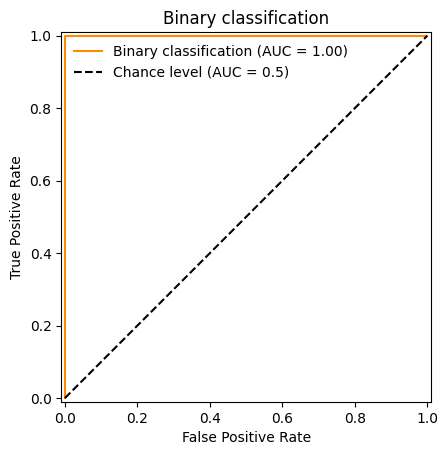

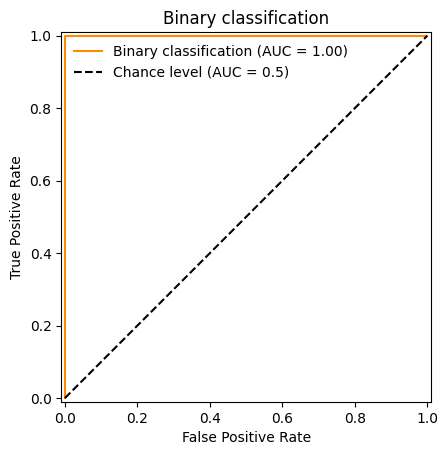

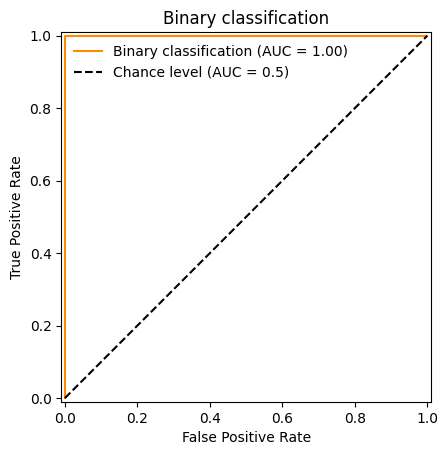

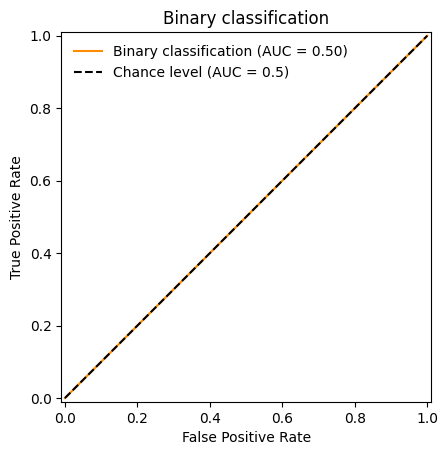

In [23]:
for model in [model_resnet, model_alexnet, model_enb0, model_swin]:
    model.eval()
    model.to(device)
    with torch.no_grad():
      for X, y in val_dataloader:
          X, y = X.to(device), y.to(device)
          out = model(X).detach().cpu()
          probs = nn.functional.softmax(out, dim=1)
          preds = probs.max(1)[1].numpy()
          labels = y.detach().cpu().numpy()

      display = RocCurveDisplay.from_predictions(
        labels,
        preds,
        name=f"Binary classification",
        color="darkorange",
        plot_chance_level=True,
      )
      _ = display.ax_.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title="Binary classification",
      )
      display.ax_.legend(frameon=False)

      print(
        'Accuracy:', accuracy_score(labels, preds),
        '\nF1-score:', f1_score(labels, preds),
        '\nRecall:', recall_score(labels, preds),
        '\nPrecision:', precision_score(labels, preds)
      )

<div class="alert alert-block alert-info">
<b>Conclude:</b> Which model gives the best performance and should be selected?
</div>

## Detection

Now that we have seen how to perform classification, we will train a detection model.
In classification, our goal was simply to assign a single label to the entire input (e.g., “normal” vs. “pneumonia”), relying on feature
extractors like ResNet or EfficientNet to encode global image cues. By contrast, detection requires both identifying and localizing multiple regions of interest—such as nodules, organs, or lesions—within a single image.

In [24]:
from torchvision.utils import draw_bounding_boxes
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")
import utils
from engine import train_one_epoch, evaluate

For detection, `Dataset` classes must be constructed differently. Observe the following one:

In [25]:
class PredictionDataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        super().__init__()

        self.image_ids = dataframe['patientId'].unique()
        self.df = dataframe
        self.image_dir = image_dir
        self.transforms = transforms

    def __getitem__(self, index: int):

        image_id = self.image_ids[index]
        records = self.df[self.df['patientId'] == image_id]

        image_dicom = pydicom.dcmread(f'{self.image_dir}/{image_id}.dcm')
        image = image_dicom.pixel_array
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB).astype(np.float32)
        image /= 255.0
        image = np.transpose(image, (2, 0, 1))
        image = tv_tensors.Image(image)
        # Define the transform
        resize_transform = torchvision.transforms.Resize((256, 256))
        # Apply the transform
        resized_img = resize_transform(image)

        boxes = records[['x', 'y', 'width', 'height']].values
        boxes[:,2] = boxes[:,0] + boxes[:,2]
        boxes[:,3] = boxes[:,1] + boxes[:,3]

        area = (boxes[:,3] - boxes[:,1]) * (boxes[:,2] - boxes[:,0])
        area = torch.as_tensor(area, dtype=torch.float64)

        # there is only one class
        labels = torch.ones((records.shape[0],), dtype=torch.int64)

        # suppose all instances are not crowd
        iscrowd = torch.zeros((records.shape[0],), dtype=torch.int64)

        target = {}
        target['boxes'] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(1024,1024))
        target['labels'] = labels
        target['patientId'] = torch.tensor([index])
        target['area'] = area
        target['iscrowd'] = iscrowd

        if self.transforms:
            image, target = self.transforms(image, target)

        return image, target

    def __len__(self) -> int:
        return self.image_ids.shape[0]

In our dataset, we have both healthy and pneumonia samples. For classification, we needed to use both. But for detection, we need to filter the dataset to only keep pneumonia samples, as the healthy ones don't have any bounding box labels.

<div class="alert alert-block alert-info">
<b>Q5.</b> Explore the structure of the labels with bounding boxes. How many positive samples (with pneumonia) are in the dataset? What proportion of images contain multiple bounding boxes?
</div>

In [26]:
# N. of positive samples
positive_samples = dataset_df[dataset_df["Target"] == 1]["patientId"].nunique()
total_samples = dataset_df["patientId"].nunique()
print(f"Positive cases: {positive_samples} / {total_samples}")

Positive cases: 298 / 994


In [27]:
# Images with multiple bbox
multiple_boxes = dataset_df[dataset_df["Target"] == 1].groupby("patientId").size()
print(f"Images with >1 bounding box: {(multiple_boxes > 1).sum()}")

Images with >1 bounding box: 6


<div class="alert alert-block alert-info">
<b>Q6.</b> Here, we visualize the bounding box on an example image. What challenges might arise in detecting these regions?
</div>

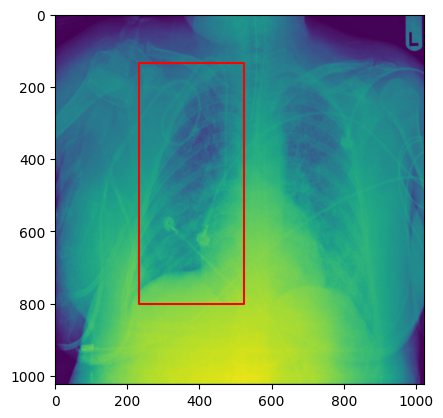

In [28]:
patient_df = dataset_df[dataset_df.Target == 1].iloc[0]
img_path = os.path.join(image_dir, "{}.dcm".format(patient_df.patientId))

plt.imshow(pydicom.dcmread(img_path).pixel_array)

img_size = 1024
x, y, w, h = patient_df[['x', 'y', 'width', 'height']].values
plt.plot([x, x, x+w, x+w, x], [y, y+h, y+h, y, y], 'red')

In this exercise, we will use Faster R-CNN. This network integrates a Region Proposal Network (RPN) directly into a two-stage detection framework. In the first stage, the RPN slides small convolutional windows over the shared feature map to generate objectness scores and bounding-box proposals. In the second stage, each proposal is cropped and reshaped via RoI pooling (or RoI Align) and passed through fully connected layers to predict refined box coordinates and classification probabilities.

In [29]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 210MB/s]


In [30]:
train_df_pos = train_df[train_df.Target == 1]
val_df_pos = val_df[val_df.Target == 1]

train_dataset = PredictionDataset(train_df_pos, image_dir, transforms=get_transform(True))
val_dataset = PredictionDataset(val_df_pos, image_dir,  transforms=get_transform(False))

train_dataloader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn = utils.collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn = utils.collate_fn
)

Let's observe what is the output of the model:

In [31]:
# For Training
images, targets = next(iter(train_dataloader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)  # Returns losses and detections
print(output)

{'loss_classifier': tensor(0.1615, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0961, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0309, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0025, dtype=torch.float64, grad_fn=<DivBackward0>)}


<div class="alert alert-block alert-info">
<b>Q6.</b> The bounding boxes are provided as (<code>x, y, width, height</code>). In the <code>Dataset</code> class, we convert them to (<code>x_min, y_min, x_max, y_max</code>) format. Why might this format be useful in practice?
</div>

<div class="alert alert-block alert-success">
Some detection frameworks expect <code>(x_min, y_min, x_max, y_max)</code> for compatibility with IoU and anchor-based matching logic.
</div>

Here, we train a FASTER-RCNN model for detection of pneumonia. Observe the following code:

In [32]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# our dataset has two classes only - background and pneumonia
num_classes = 2

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

num_epochs = 5
model.to(device)
for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, train_dataloader, device, epoch, print_freq=1000)
    # update the learning rate
    lr_scheduler.step()

torch.save(model.state_dict(), './fasterrcnn_resnet50_fpn.pth')

Epoch: [0]  [  0/213]  eta: 0:03:08  lr: 0.000029  loss: 0.1735 (0.1735)  loss_classifier: 0.0545 (0.0545)  loss_box_reg: 0.0045 (0.0045)  loss_objectness: 0.0983 (0.0983)  loss_rpn_box_reg: 0.0163 (0.0163)  time: 0.8870  data: 0.0135  max mem: 18392
Epoch: [0]  [212/213]  eta: 0:00:00  lr: 0.005000  loss: 0.1931 (0.2258)  loss_classifier: 0.0809 (0.0999)  loss_box_reg: 0.0848 (0.0951)  loss_objectness: 0.0159 (0.0260)  loss_rpn_box_reg: 0.0026 (0.0049)  time: 0.0970  data: 0.0129  max mem: 18392
Epoch: [0] Total time: 0:00:21 (0.1005 s / it)
Epoch: [1]  [  0/213]  eta: 0:00:20  lr: 0.005000  loss: 0.1905 (0.1905)  loss_classifier: 0.0813 (0.0813)  loss_box_reg: 0.0914 (0.0914)  loss_objectness: 0.0145 (0.0145)  loss_rpn_box_reg: 0.0032 (0.0032)  time: 0.0962  data: 0.0133  max mem: 18392
Epoch: [1]  [212/213]  eta: 0:00:00  lr: 0.005000  loss: 0.2080 (0.2199)  loss_classifier: 0.0816 (0.0975)  loss_box_reg: 0.0972 (0.1018)  loss_objectness: 0.0124 (0.0164)  loss_rpn_box_reg: 0.0027 (0

<div class="alert alert-block alert-info">
<b>Q7.</b> Similarly, complete the following code to train a RetinaNet model.
</div>

In [53]:
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

train_df_pos = train_df[train_df.Target == 1]
val_df_pos = val_df[val_df.Target == 1]

train_dataset = PredictionDataset(train_df_pos, image_dir, transforms=get_transform(True))
val_dataset = PredictionDataset(val_df_pos, image_dir,  transforms=get_transform(False))

train_dataloader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn = utils.collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn = utils.collate_fn
)

# Load pretrained RetinaNet
model = retinanet_resnet50_fpn(pretrained=True)

# our dataset has two classes only - background and person
num_classes = 2

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

num_epochs = 5
model.to(device)
for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, train_dataloader, device, epoch, print_freq=1000)
    # update the learning rate
    lr_scheduler.step()

torch.save(model.state_dict(), './retinanet_resnet50_fpn.pth')

Epoch: [0]  [  0/213]  eta: 0:00:24  lr: 0.000029  loss: 1.9549 (1.9549)  classification: 1.2106 (1.2106)  bbox_regression: 0.7443 (0.7443)  time: 0.1132  data: 0.0140  max mem: 18392
Epoch: [0]  [212/213]  eta: 0:00:00  lr: 0.005000  loss: 1.0615 (1.1379)  classification: 0.5194 (0.6026)  bbox_regression: 0.5413 (0.5353)  time: 0.1077  data: 0.0122  max mem: 18392
Epoch: [0] Total time: 0:00:23 (0.1081 s / it)
Epoch: [1]  [  0/213]  eta: 0:00:23  lr: 0.005000  loss: 1.2629 (1.2629)  classification: 0.6885 (0.6885)  bbox_regression: 0.5743 (0.5743)  time: 0.1084  data: 0.0137  max mem: 18392
Epoch: [1]  [212/213]  eta: 0:00:00  lr: 0.005000  loss: 0.9983 (1.0938)  classification: 0.4748 (0.5817)  bbox_regression: 0.4960 (0.5121)  time: 0.1082  data: 0.0135  max mem: 18392
Epoch: [1] Total time: 0:00:22 (0.1079 s / it)
Epoch: [2]  [  0/213]  eta: 0:00:23  lr: 0.005000  loss: 1.0306 (1.0306)  classification: 0.5165 (0.5165)  bbox_regression: 0.5141 (0.5141)  time: 0.1085  data: 0.0143  m

In [54]:
def calculate_precision(gts, preds, threshold = 0.5, form = 'coco', ious=None) -> float:
    # https://www.kaggle.com/sadmanaraf/wheat-detection-using-faster-rcnn-train
    """Calculates precision for GT - prediction pairs at one threshold.

    Args:
        gts: (List[List[Union[int, float]]]) Coordinates of the available ground-truth boxes
        preds: (List[List[Union[int, float]]]) Coordinates of the predicted boxes,
               sorted by confidence value (descending)
        threshold: (float) Threshold
        form: (str) Format of the coordinates
        ious: (np.ndarray) len(gts) x len(preds) matrix for storing calculated ious.

    Return:
        (float) Precision
    """
    n = len(preds)
    tp = 0
    fp = 0

    for pred_idx in range(n):

        best_match_gt_idx = find_best_match(gts, preds[pred_idx], pred_idx,
                                            threshold=threshold, form=form, ious=ious)

        if best_match_gt_idx >= 0:
            # True positive: The predicted box matches a gt box with an IoU above the threshold.
            tp += 1
            # Remove the matched GT box
            gts[best_match_gt_idx] = -1
        else:
            # No match
            # False positive: indicates a predicted box had no associated gt box.
            fp += 1

    # False negative: indicates a gt box had no associated predicted box.
    fn = (gts.sum(axis=1) > 0).sum()

    return tp / (tp + fp + fn)

def calculate_image_precision(gts, preds, thresholds = (0.5, ), form = 'coco') -> float:
    # https://www.kaggle.com/sadmanaraf/wheat-detection-using-faster-rcnn-train
    """Calculates image precision.

    Args:
        gts: (List[List[Union[int, float]]]) Coordinates of the available ground-truth boxes
        preds: (List[List[Union[int, float]]]) Coordinates of the predicted boxes,
               sorted by confidence value (descending)
        thresholds: (float) Different thresholds
        form: (str) Format of the coordinates

    Return:
        (float) Precision
    """
    n_threshold = len(thresholds)
    image_precision = 0.0

    ious = np.ones((len(gts), len(preds))) * -1
    # ious = None

    for threshold in thresholds:
        precision_at_threshold = calculate_precision(gts.copy(), preds, threshold=threshold,
                                                     form=form, ious=ious)
        image_precision += precision_at_threshold / n_threshold

    return image_precision

def find_best_match(gts, pred, pred_idx, threshold = 0.5, form = 'pascal_voc', ious=None) -> int:
    # https://www.kaggle.com/sadmanaraf/wheat-detection-using-faster-rcnn-train
    """Returns the index of the 'best match' between the
    ground-truth boxes and the prediction. The 'best match'
    is the highest IoU. (0.0 IoUs are ignored).

    Args:
        gts: (List[List[Union[int, float]]]) Coordinates of the available ground-truth boxes
        pred: (List[Union[int, float]]) Coordinates of the predicted box
        pred_idx: (int) Index of the current predicted box
        threshold: (float) Threshold
        form: (str) Format of the coordinates
        ious: (np.ndarray) len(gts) x len(preds) matrix for storing calculated ious.

    Return:
        (int) Index of the best match GT box (-1 if no match above threshold)
    """
    best_match_iou = -np.inf
    best_match_idx = -1
    for gt_idx in range(len(gts)):

        if gts[gt_idx][0] < 0:
            # Already matched GT-box
            continue

        iou = -1 if ious is None else ious[gt_idx][pred_idx]

        if iou < 0:
            iou = calculate_iou(gts[gt_idx], pred, form=form)

            if ious is not None:
                ious[gt_idx][pred_idx] = iou

        if iou < threshold:
            continue

        if iou > best_match_iou:
            best_match_iou = iou
            best_match_idx = gt_idx

    return best_match_idx

def calculate_iou(gt, pr, form='pascal_voc') -> float:
    # https://www.kaggle.com/sadmanaraf/wheat-detection-using-faster-rcnn-train
    """Calculates the Intersection over Union.

    Args:
        gt: (np.ndarray[Union[int, float]]) coordinates of the ground-truth box
        pr: (np.ndarray[Union[int, float]]) coordinates of the prdected box
        form: (str) gt/pred coordinates format
            - pascal_voc: [xmin, ymin, xmax, ymax]
            - coco: [xmin, ymin, w, h]
    Returns:
        (float) Intersection over union (0.0 <= iou <= 1.0)
    """
    if form == 'coco':
        gt = gt.copy()
        pr = pr.copy()

        gt[2] = gt[0] + gt[2]
        gt[3] = gt[1] + gt[3]
        pr[2] = pr[0] + pr[2]
        pr[3] = pr[1] + pr[3]

    # Calculate overlap area
    dx = min(gt[2], pr[2]) - max(gt[0], pr[0]) + 1

    if dx < 0:
        return 0.0
    dy = min(gt[3], pr[3]) - max(gt[1], pr[1]) + 1

    if dy < 0:
        return 0.0

    overlap_area = dx * dy

    # Calculate union area
    union_area = (
            (gt[2] - gt[0] + 1) * (gt[3] - gt[1] + 1) +
            (pr[2] - pr[0] + 1) * (pr[3] - pr[1] + 1) -
            overlap_area
    )

    return overlap_area / union_area

In [55]:
precisions = []
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.load_state_dict(torch.load('./fasterrcnn_resnet50_fpn.pth'))
model.eval()
model.to(device)
with torch.no_grad():
  for images, targets in val_dataloader:
    images = list(image.to(device) for image in images)
    targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
    outputs = model(images)
    outputs = [{k: v.to('cpu') for k, v in t.items()} for t in outputs]
    precisions.append(calculate_image_precision(targets[0]['boxes'].detach().cpu().numpy(), outputs[0]['boxes'].detach().cpu().numpy()))

  print('Average precision:', np.mean(precisions))

Average precision: 0.08548837628452233


<div class="alert alert-block alert-info">
<b>Q8.</b> Compare the precision of the two models. Which one performs best? Why?
</div>

<div class="alert alert-block alert-success">
Faster R-CNN tends to perform better on datasets with fewer objects per image and high localization precision — good for medical use.
RetinaNet uses Focal Loss and may be more robust to class imbalance.
In RSNA, Faster R-CNN pretrained on COCO generally performs better out-of-the-box.
</div>

In [56]:
# Load pretrained RetinaNet
model = retinanet_resnet50_fpn(pretrained=True)

precisions = []
model.load_state_dict(torch.load('./retinanet_resnet50_fpn.pth'))
model.eval()
model.to(device)
with torch.no_grad():
  for images, targets in val_dataloader:
    images = list(image.to(device) for image in images)
    targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
    outputs = model(images)
    outputs = [{k: v.to('cpu') for k, v in t.items()} for t in outputs]
    precisions.append(calculate_image_precision(targets[0]['boxes'].detach().cpu().numpy(), outputs[0]['boxes'].detach().cpu().numpy()))

  print('Average precision:', np.mean(precisions))

Average precision: 0.017479978646617832


<div class="alert alert-block alert-info">
<b>Q9.</b> The RSNA challenge uses IoU (Intersection over Union) and mAP (mean Average Precision). Implement IoU between two bounding boxes and compute the score on validation data. Why is IoU a better fit than accuracy for detection?
</div>

<div class="alert alert-block alert-success">
It evaluates spatial overlap, not just correctness of presence/absence, which is crucial for localizing lesions.
</div>

In [57]:
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2Area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = interArea / float(box1Area + box2Area - interArea)
    return iou

<div class="alert alert-block alert-info">
<b>Conclude.</b> Compare the performance of the two trained models and justify your selection based on multiple criterias, including computing time.
</div>

In [58]:
def evaluate_model(model, dataloader, device, iou_threshold=0.5, conf_threshold=0.5):
    model.eval()
    all_precisions = []
    all_recalls = []
    all_ious = []

    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)

            for pred, target in zip(outputs, targets):
                gt_boxes = target['boxes'].cpu().numpy()
                pred_boxes = pred['boxes'].cpu().numpy()
                pred_scores = pred['scores'].cpu().numpy()

                # Filter by confidence
                pred_boxes = pred_boxes[pred_scores > conf_threshold]

                # Compute IoUs
                matched = set()
                ious = []
                for gt_box in gt_boxes:
                    best_iou = 0
                    for i, pred_box in enumerate(pred_boxes):
                        if i in matched:
                            continue
                        iou = compute_iou(gt_box, pred_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_idx = i
                    if best_iou >= iou_threshold:
                        matched.add(best_idx)
                        ious.append(best_iou)

                TP = len(matched)
                FP = len(pred_boxes) - TP
                FN = len(gt_boxes) - TP

                precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                recall = TP / (TP + FN) if (TP + FN) > 0 else 0

                all_precisions.append(precision)
                all_recalls.append(recall)
                all_ious.extend(ious)

    return {
        "precision": np.mean(all_precisions),
        "recall": np.mean(all_recalls),
        "mean_iou": np.mean(all_ious) if all_ious else 0
    }

In [60]:
# Evaluate Faster R-CNN
faster_rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
faster_rcnn_model.load_state_dict(torch.load('./fasterrcnn_resnet50_fpn.pth'))
faster_rcnn_model.to(device)
faster_rcnn_results = evaluate_model(faster_rcnn_model, val_dataloader, device)

# Evaluate RetinaNet
retinanet_model = retinanet_resnet50_fpn(pretrained=True)
retinanet_model.load_state_dict(torch.load('./retinanet_resnet50_fpn.pth'))
retinanet_model.to(device)
retinanet_results = evaluate_model(retinanet_model, val_dataloader, device)

# Print comparison
print("Faster R-CNN Results:")
print(f"Precision: {faster_rcnn_results['precision']:.3f}")
print(f"Recall: {faster_rcnn_results['recall']:.3f}")
print(f"Mean IoU: {faster_rcnn_results['mean_iou']:.3f}\n")

print("RetinaNet Results:")
print(f"Precision: {retinanet_results['precision']:.3f}")
print(f"Recall: {retinanet_results['recall']:.3f}")
print(f"Mean IoU: {retinanet_results['mean_iou']:.3f}")

Faster R-CNN Results:
Precision: 0.236
Recall: 0.552
Mean IoU: 0.699

RetinaNet Results:
Precision: 0.000
Recall: 0.000
Mean IoU: 0.000
